In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, precision_recall_curve, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans

In [4]:
# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())
print(df.info())
print("shape", df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
# Convert TotalCharges to Numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [6]:
# Define Target variable: Early Churn
df['Earlychurn'] = ((df['Churn'] == 'Yes') & (df['tenure'] <= 3)).astype(int)
df['Earlychurn'].value_counts()

Earlychurn
0    6446
1     597
Name: count, dtype: int64

In [7]:
early_churn_rate = df['Earlychurn'].mean()
print(f"Early churn rate: {early_churn_rate:.2%}")


Early churn rate: 8.48%


In [8]:
# How Many Customers Churn Early
early_churn_count = df ['Earlychurn'].sum()
total_customers = len(df)

print(f"Early churn customers: {early_churn_count}")
print(f"Total customer: {total_customers}")

Early churn customers: 597
Total customer: 7043


In [9]:
# Encode Binary Columns
binary_cols = [
    'Partner','Dependents','PhoneService','PaperlessBilling',
    'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
    'StreamingTV','StreamingMovies','Churn'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [10]:
# One-hot encode categorical features
one_hot_cols = ['PaymentMethod', 'InternetService', 'Contract', 'MultipleLines']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)


In [11]:
# Encode gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})


In [12]:
# Scale numeric features
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [13]:
# Prepare features and target
X = df.drop(['customerID', 'Churn', 'Earlychurn'], axis=1)
y = df['Earlychurn']

In [14]:
# Impute missing values
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


In [15]:
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


In [16]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.25, random_state=42, stratify=y_resampled
)

In [17]:
# Define and train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42)
}

In [18]:
# Evaluate Models
results = []

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

pd.DataFrame(results)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4835, number of negative: 4834
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3291
[LightGBM] [Info] Number of data points in the train set: 9669, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500052 -> initscore=0.000207
[LightGBM] [Info] Start training from score 0.000207


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.923519,0.996896,0.958806,0.982600
1,Random Forest,0.961841,0.985723,0.973636,0.994306
2,XGBoost,0.957831,0.986965,0.972180,0.995632
3,LightGBM,0.961772,0.983861,0.972691,0.995351


In [19]:
# Initialize models
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
lgb_model = LGBMClassifier(random_state=42)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4835, number of negative: 4834
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3291
[LightGBM] [Info] Number of data points in the train set: 9669, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500052 -> initscore=0.000207
[LightGBM] [Info] Start training from score 0.000207


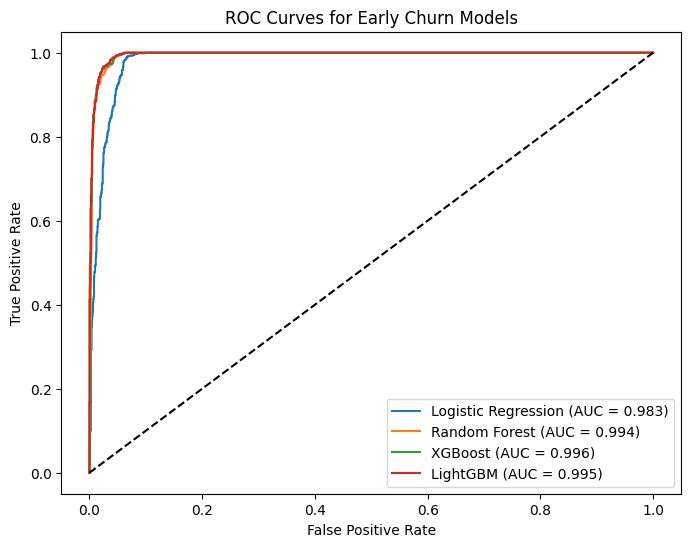

In [20]:
# ROC Curves for Early Churn Models
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define models (these are unfitted initially)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42)
}

# Fit the models (if not already done in a previous cell)
for name, model in models.items():
    model.fit(X_train, y_train)

# Now plot ROC curves
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Early Churn Models")
plt.legend()
plt.show()

In [21]:
# Use LightGBM for further analysis (best performer)
lgb_model = models["LightGBM"]

In [22]:
# Optimize threshold using Precision-Recall curve
y_probs = lgb_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold}")

Best threshold: 0.23625363737175684


In [23]:
# Predictions with optimal threshold
y_pred_opt = (y_probs >= best_threshold).astype(int)

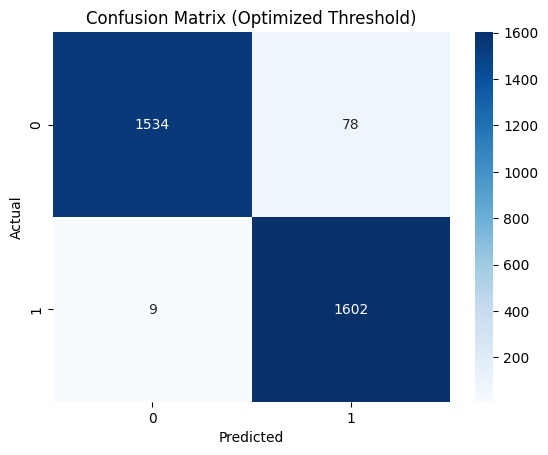

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1612
           1       0.95      0.99      0.97      1611

    accuracy                           0.97      3223
   macro avg       0.97      0.97      0.97      3223
weighted avg       0.97      0.97      0.97      3223



In [24]:
# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Optimized Threshold)")
plt.show()
print(classification_report(y_test, y_pred_opt))


In [25]:
# Business cost calculation (assuming costs: FN=500, FP=50, TP=-400)
tn, fp, fn, tp = cm.ravel()
cost_opt = (fn * 500) + (fp * 50) - (tp * 400)
print(f"Total business cost at optimized threshold: {cost_opt}")


Total business cost at optimized threshold: -632400


In [26]:
# Compare with default threshold (0.5)
y_pred_default = (y_probs >= 0.5).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)
tn_d, fp_d, fn_d, tp_d = cm_default.ravel()
cost_default = (fn_d * 500) + (fp_d * 50) - (tp_d * 400)
print(f"Cost at default threshold (0.5): {cost_default}")
print(f"Savings: {cost_default - cost_opt}")

Cost at default threshold (0.5): -617850
Savings: 14550


In [27]:
# Churn segmentation on early churners
churn_data = df[df['Earlychurn'] == 1].copy()
seg_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_seg = churn_data[seg_features]


In [28]:
# Scale for clustering
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

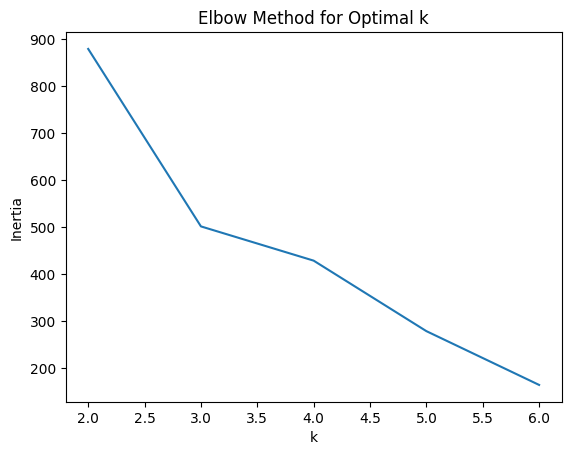

In [29]:
# Determine optimal k (elbow method)
inertia = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_seg_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [30]:
# Fit KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
churn_data['Segment'] = kmeans.fit_predict(X_seg_scaled)  # Assign cluster labels


In [31]:
# Segment labels based on means (customize as needed)
segment_means = churn_data.groupby('Segment')[seg_features].mean()
segment_map = {0: "Price-Sensitive", 1: "Low-Engagement", 2: "Onboarding Failure"}
churn_data['SegmentLabel'] = churn_data['Segment'].map(segment_map)


In [32]:
# Service usage patterns
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
service_profile = churn_data.groupby('Segment')[service_cols].mean()
print("Service Usage Patterns per Segment:")
print(service_profile)

Service Usage Patterns per Segment:
         OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
Segment                                                                
0              0.054795      0.095890          0.105023     0.027397   
1              0.079755      0.159509          0.214724     0.122699   
2              0.089655      0.131034          0.096552     0.089655   

         StreamingTV  StreamingMovies  
Segment                                
0           0.278539         0.260274  
1           0.368098         0.337423  
2           0.082759         0.110345  


In [33]:
df['MonthlyCharges_raw'] = df['MonthlyCharges']
df['TotalCharges_raw'] = df['TotalCharges']


In [34]:
# Revenue loss estimation (using original MonthlyCharges, not scaled)
churn_data['RevenueLost'] = churn_data['MonthlyCharges'] * 12  # Assuming 12 months potential revenue
segment_revenue = churn_data.groupby('Segment')['RevenueLost'].sum()
segment_count = churn_data['Segment'].value_counts()
segment_impact = pd.concat([segment_count, segment_revenue], axis=1)
segment_impact.columns = ['ChurnCount', 'EstimatedRevenueLost']
segment_impact['AvgLossPerCustomer'] = segment_impact['EstimatedRevenueLost'] / segment_impact['ChurnCount']
print("Segment Impact:")
print(segment_impact)

Segment Impact:
         ChurnCount  EstimatedRevenueLost  AvgLossPerCustomer
Segment                                                      
0               219           1008.380820            4.604479
2               215          -2619.589207          -12.184136
1               163            720.207184            4.418449


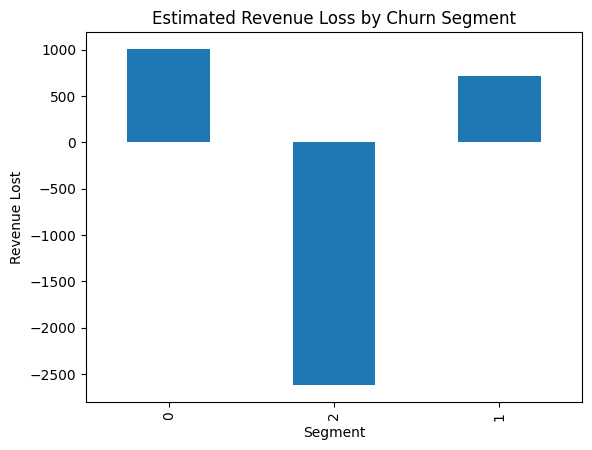

In [35]:
# Plot revenue loss
segment_impact['EstimatedRevenueLost'].plot(kind='bar', title='Estimated Revenue Loss by Churn Segment')
plt.ylabel('Revenue Lost')
plt.show()

Hyperparameter Tuning

In [36]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 50],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}


In [37]:
lgb_base = LGBMClassifier(random_state=42)

search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4835, number of negative: 4834
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001753 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3291
[LightGBM] [Info] Number of data points in the train set: 9669, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500052 -> initscore=0.000207
[LightGBM] [Info] Start training from score 0.000207


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [44]:
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)


Best params: {'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 15, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.9959274770331257


Feature Importance & Interpretation

In [49]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [50]:
hasattr(log_model, "coef_")


True

               Feature  Coefficient
4               tenure   -15.143485
14        TotalCharges    -9.334197
20   Contract_One year    -1.588122
21   Contract_Two year    -1.211587
6       OnlineSecurity    -0.931498
13      MonthlyCharges     0.763206
9          TechSupport    -0.759452
19  InternetService_No    -0.668431
12    PaperlessBilling     0.577359
7         OnlineBackup    -0.575924


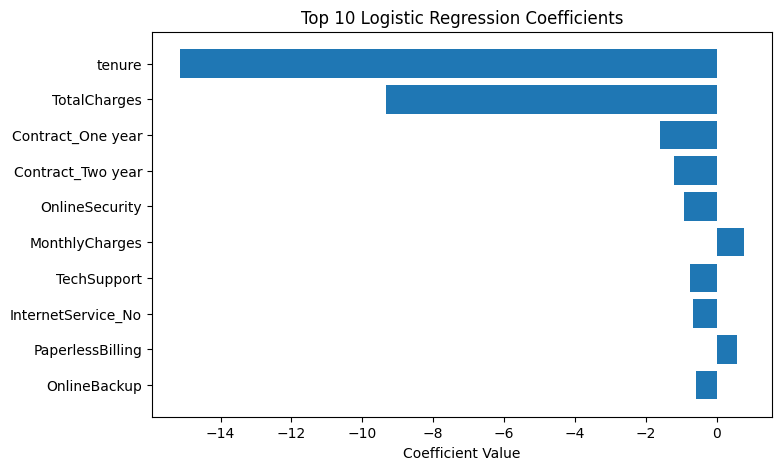

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names
feature_names = X_train.columns

# Extract coefficients
log_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

# Top 10 influential features
top_log = log_coefs.head(10)
print(top_log)

# Plot
plt.figure(figsize=(8,5))
plt.barh(top_log["Feature"], top_log["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.show()


                       Feature  Importance
13              MonthlyCharges        2777
14                TotalCharges        1635
4                       tenure         871
0                       gender         432
12            PaperlessBilling         393
2                      Partner         313
3                   Dependents         268
23           MultipleLines_Yes         236
7                 OnlineBackup         228
17  PaymentMethod_Mailed check         224


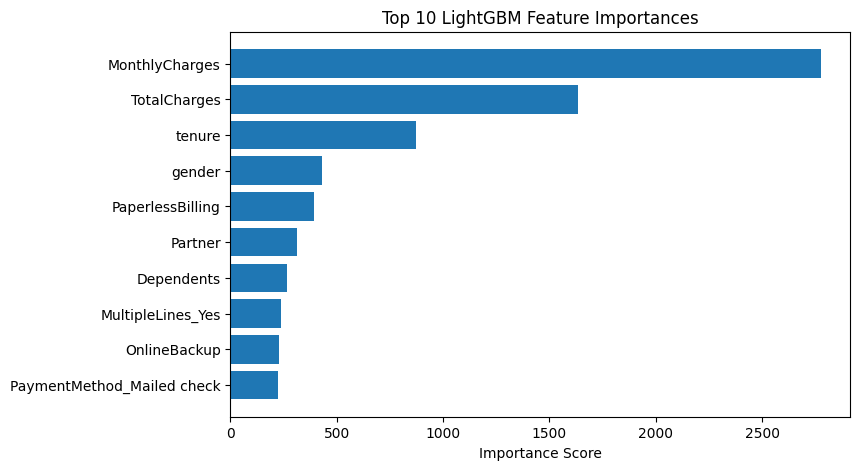

In [46]:
# Extract importance
lgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_lgb = lgb_importance.head(10)
print(top_lgb)

# Plot
plt.figure(figsize=(8,5))
plt.barh(top_lgb["Feature"], top_lgb["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 LightGBM Feature Importances")
plt.xlabel("Importance Score")
plt.show()


SHAP — Global + Per-Customer Explanation

e:\#Fourth sem\Applied Machine Learning\assignment\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


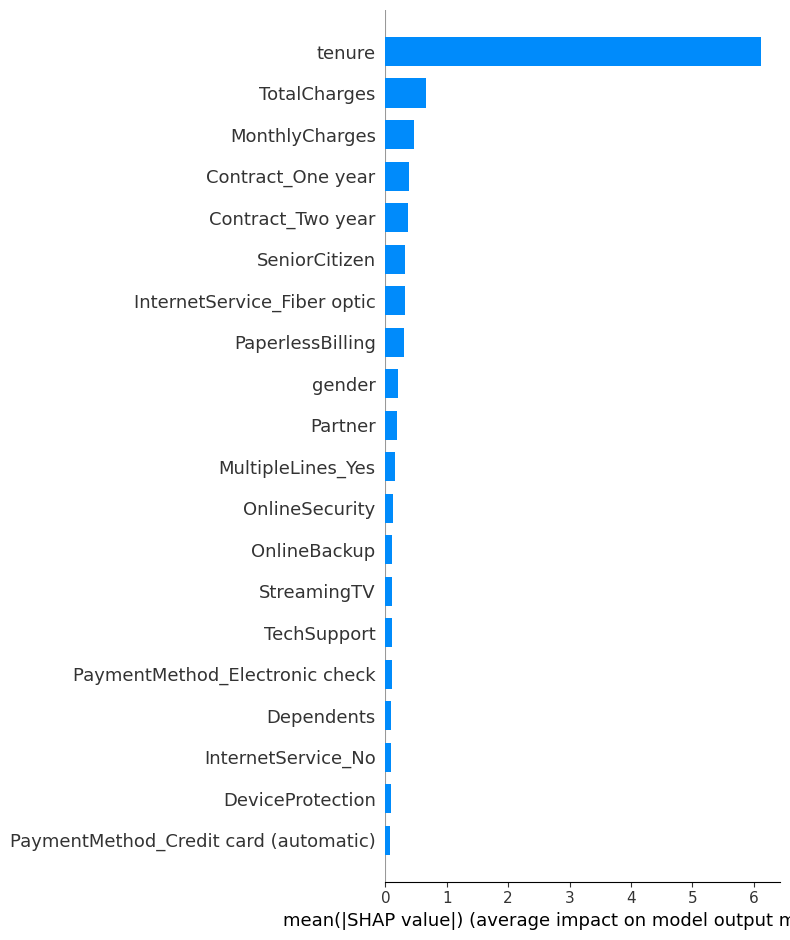

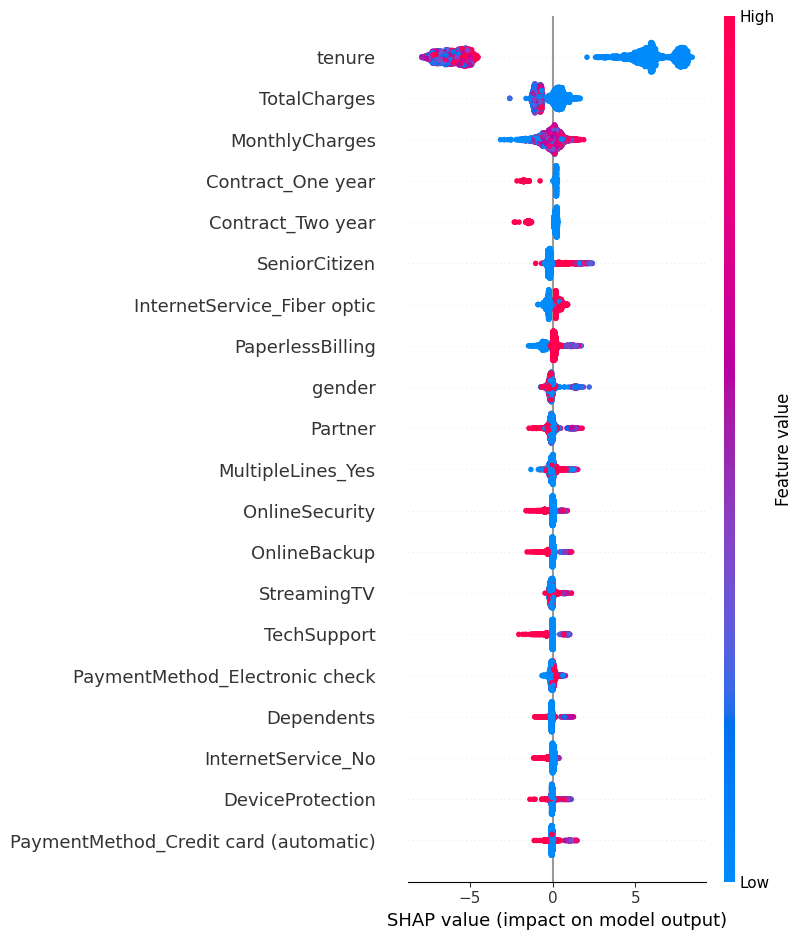

In [47]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# Global explanation
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed global view
shap.summary_plot(shap_values, X_test)


In [48]:
# Pick one customer
i = 0
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i]
)


In [55]:
trained_features = X_train.columns


In [56]:
X_all = df.copy()

# Drop non-features
X_all = X_all.drop(['customerID', 'Churn', 'Earlychurn'], axis=1)

# Drop columns never used during training
extra_cols = set(X_all.columns) - set(trained_features)
X_all = X_all.drop(columns=extra_cols)

# Add missing columns (if any) with 0
missing_cols = set(trained_features) - set(X_all.columns)
for col in missing_cols:
    X_all[col] = 0

# Reorder columns exactly like training
X_all = X_all[trained_features]

# Impute
X_all = pd.DataFrame(imputer.transform(X_all), columns=trained_features)


In [57]:
df['EarlyChurn_Prob'] = lgb_model.predict_proba(X_all)[:,1]


In [58]:
print(set(X_all.columns) - set(trained_features))
print(set(trained_features) - set(X_all.columns))


set()
set()


Get prediction probabilities

In [61]:
df['Earlychurn_Prob'] = lgb_model.predict_proba(X_all)[:,1]

df['RiskLevel'] = pd.cut(
    df['EarlyChurn_Prob'],
    bins=[0, best_threshold, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)


LightGBMError: The number of features in data (27) is not the same as it was in training data (24).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [54]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Earlychurn', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'MonthlyCharges_raw', 'TotalCharges_raw'],
      dtype='object')


Dead End

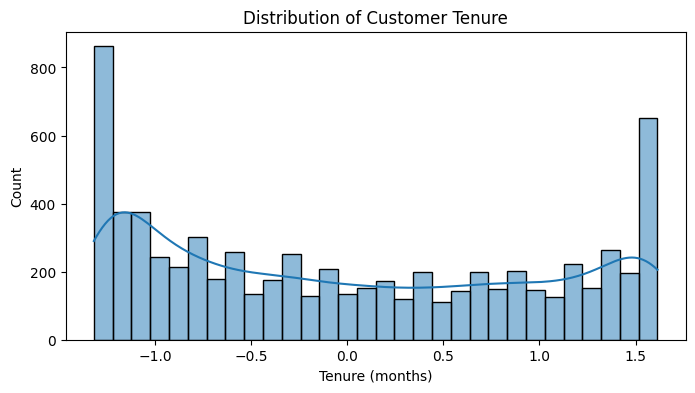

In [38]:
# Tenure Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

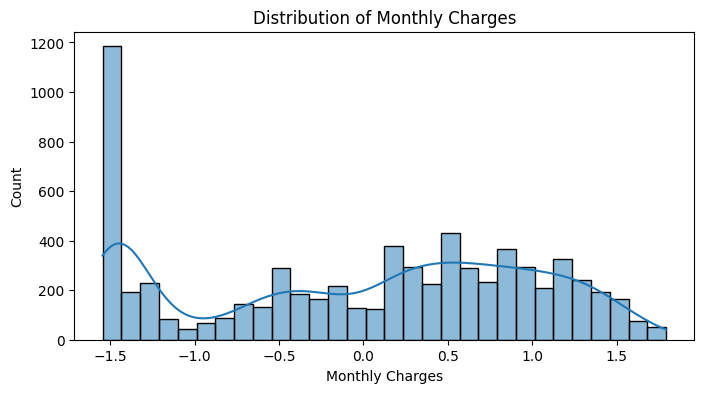

In [39]:
# Monthly Charges Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()


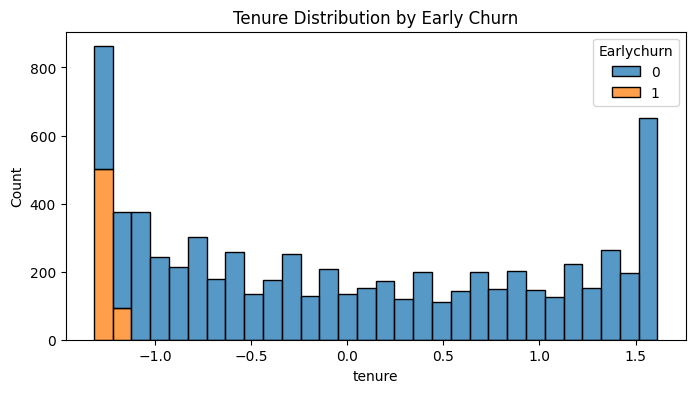

In [40]:
# Early Churn vs Tenure
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Earlychurn', bins=30, multiple='stack')
plt.title("Tenure Distribution by Early Churn")
plt.show()


In [41]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_dummy = dummy.predict(X_test)
y_dummy_prob = dummy.predict_proba(X_test)[:,1]

print("Baseline ROC-AUC:", roc_auc_score(y_test, y_dummy_prob))
print(classification_report(y_test, y_dummy))


Baseline ROC-AUC: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1612
           1       0.50      1.00      0.67      1611

    accuracy                           0.50      3223
   macro avg       0.25      0.50      0.33      3223
weighted avg       0.25      0.50      0.33      3223



e:\#Fourth sem\Applied Machine Learning\assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\#Fourth sem\Applied Machine Learning\assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\#Fourth sem\Applied Machine Learning\assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    X_resampled, y_resampled,
    scoring="roc_auc",
    cv=cv
)

print("CV ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std:", cv_scores.std())


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5157, number of negative: 5156
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3496
[LightGBM] [Info] Number of data points in the train set: 10313, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500048 -> initscore=0.000194
[LightGBM] [Info] Start training from score 0.000194
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5156, number of negative: 5157
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wis

e:\#Fourth sem\Applied Machine Learning\assignment\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


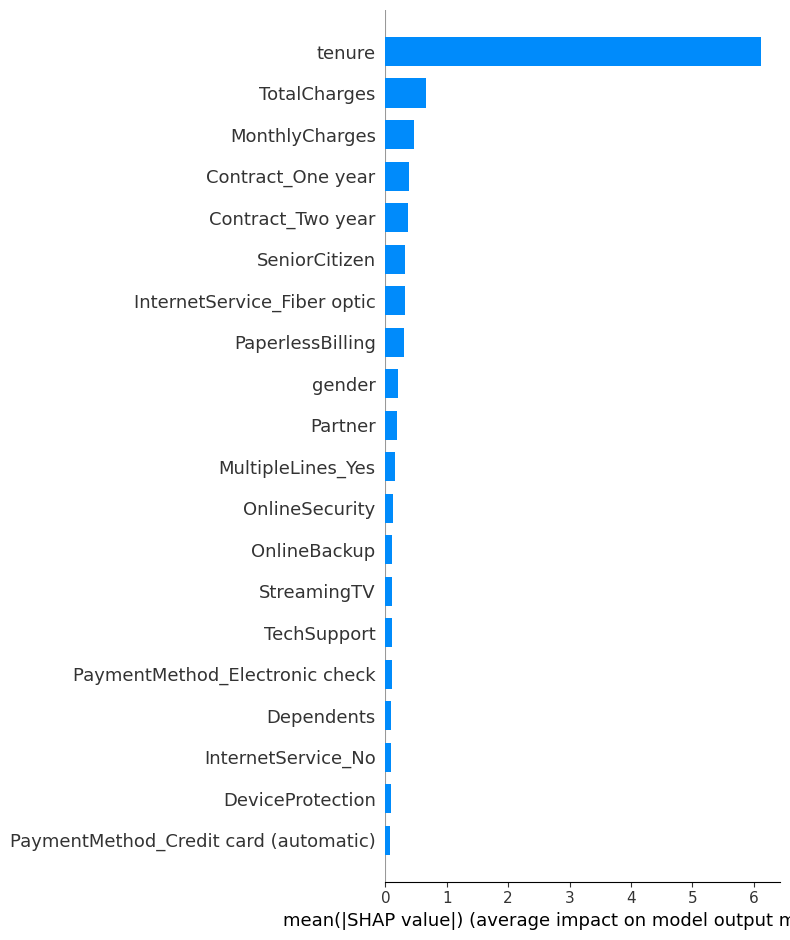

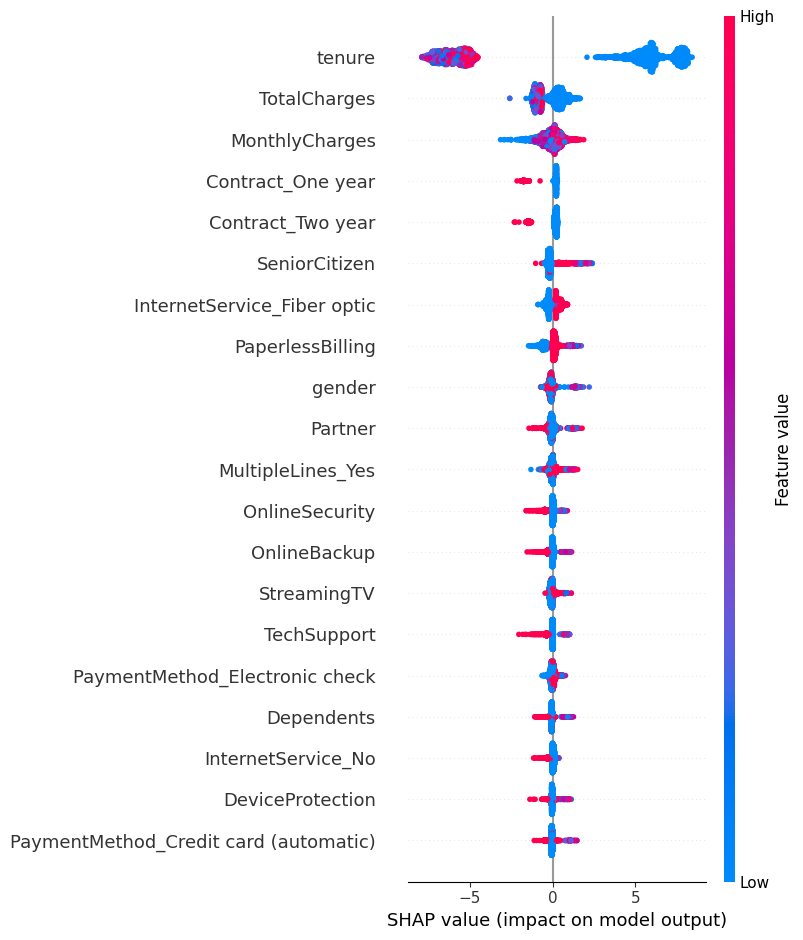

In [43]:
import shap

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)
